# EXAMPLE-1: mini RSA with identity padding in quantum circuit with qiskit
dr. kornpob bhirombhakdi 2026-Oct-6

1. this example demonstrates a quantum circuit implementation (qiskit, python3) of RSA encryption/decryption.
2. modular exponentiation is implemented as a reversible oracle `U_k: |x>|y> -> |x>|y XOR (x^k mod N)>`. the same builder is used for both directions: public-key `e` encrypts (`C = M^e mod N`) and private-key `d` decrypts (`M = C^d mod N`).
3. flow: `M(bits) -> M(int) -> padding -> encrypt -> serialize -> transmit/receive -> deserialize -> decrypt -> depadding -> MESSAGE`. padding is the identity here, so the integer goes straight through.
4. usage: set `testcase = (M_bits, p, q, e)` and run. the message value must be smaller than `N = p*q`, and `N` must fit in `n = N.bit_length()` qubits per register (`2n` qubits in total).
5. limitations: the oracle is a lookup table. `x^k mod N` is computed classically for every `x < N` and baked into the circuit as multi-controlled X gates, so gate count grows exponentially with `n`. this is a demonstration of the circuit structure, not a scalable quantum modular exponentiation (which needs modular adders and multipliers with ancilla qubits). identity padding and tiny primes are also not secure, so this is for learning only.

In [50]:
"""
EXAMPLE-1: mini RSA with identity padding
testcase: M=010, p,q=3,5, e=3, (N=15, phi=8, d=3)
flow: M(bits) -> M(int) -> padding -> encrypt -> serialize -> transmit/receive -> deserialize -> decrypt -> depadding -> MESSAGE
"""
# !pip install qiskit qiskit-aer

from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit_aer import AerSimulator
from math import gcd, isqrt

# ---- reversible oracle: |x>|y> -> |x>|y XOR (x^k mod N)>, x = 0..N-1 ----
# k is an integer key (k = e to encrypt, k = d to decrypt), not a symbolic exponent
def modexp_oracle(qc, src, dst, k, n, N):
    for x in range(N):
        out = pow(x, k, N)
        for bit in range(n):
            if (out >> bit) & 1:
                qc.mcx(list(src), dst[bit], ctrl_state=x)

def load_integer(qc, reg, value):
    """set register to basis state |value>  (qubit i = bit i of value)"""
    for i in range(len(reg)):
        if (value >> i) & 1:
            # note operator `value >> i` shifts value in bin-expression by i-bin-digit to the right
            # example: if value = 0110101
            # value >> 1 --> 011010[:1 dropped] 
            # value >> 2 --> 01101[:01 dropped]
            qc.x(reg[i]) # circuit is modified in-place

def init_circuit(n):
    """registers + empty circuit (n input qubits, n output qubits, n classical bits)"""
    a = QuantumRegister(n, "in")
    b = QuantumRegister(n, "out")
    c = ClassicalRegister(n, "res")
    qc = QuantumCircuit(a, b, c)
    return qc, a, b, c

def run_oracle(value, k, n, N):
    """load |value>, apply U_k, measure output register, return integer"""
    # value,k = (M_padded, e) for encryption, (C, d) for decryption
    qc, a, b, c = init_circuit(n)
    qc.barrier()
    load_integer(qc, a, value)
    qc.barrier()
    modexp_oracle(qc, a, b, k, n, N)
    qc.barrier()
    qc.measure(b, c) # arguments measure(qubit, cbit)
    sim = AerSimulator()
    counts = sim.run(transpile(qc, sim), shots=100).result().get_counts()
    return int(max(counts, key=counts.get), 2), qc

In [83]:
##### testcase = (M_bits,p,q,e)
testcase = ("010",3,5,3)
# testcase = ("101",3,5,3)
# testcase = ("011",3,7,5)
# testcase = ("011",3,11,3)
# testcase = ("011",11,13,7)
# testcase = ("01101",11,13,7)
# testcase = ("011011",11,13,7)
# testcase = ("0110101",11,13,7)
# testcase = ("01100101",11,13,7)
# testcase = ("011001011",11,13,7) # expect fail

In [84]:
##### stress test
# testcase = ("011001011", 11, 19, 7)  # N=209,  n=8,  16 qubits  (done) ~1second
# need M < N; use int(M)=N-1 for worst case:
# testcase = ("0110101110", 23, 29, 3)       # N=667,  n=10, 20 qubits (e=3: gcd(3,616)=1) ~4seconds
# testcase = ("10001111010", 31, 37, 7)      # M=1146=N-1, N=1147, n=11, 22 qubits (~1 min) ~20seconds
# testcase = ("01111111111", 61, 67, 7)      # M=1023, N=4087, n=12, 24 qubits (slow, minutes) ~247seconds

In [85]:
##### edge cases
# testcase = ("11111101", 11, 23, 7)   # expect fail # N=253, just under 2^8: register almost fully used, M=253? no: 11111101=253 > N-1 -> expect FAIL (value >= N? 253 >= 253)
# testcase = ("11111100", 11, 23, 7)   # expect pass pair # M=252=N-1, N=253, n=8

In [86]:
from datetime import datetime, timezone

M_bits,p,q,e = testcase
local_now = datetime.now()

# ---- key setup (classical) ----
N, phi = p * q, (p - 1) * (q - 1)
d = pow(e, -1, phi)
m = len(M_bits)                          # message bits
n = N.bit_length()             # qubits per register = ceil(log2 N) = 4

###############
###############

def is_prime(x):
    return x > 1 and all(x % i for i in range(2, isqrt(x) + 1))

assert is_prime(p) and is_prime(q)         # p, q prime
assert p < q                               # distinct, so phi = (p-1)(q-1) is valid
assert p % 2 == 1 and q % 2 == 1           # odd primes
assert 1 < e < phi and gcd(e, phi) == 1    # e invertible mod phi
assert (d * e) % phi == 1                  # d is the inverse of e
# assert 2**m <= N                           # message fits RSA range
assert N <= 2**n                           # register holds 0..N-1
assert all(pow(pow(M, e, N), d, N) == M for M in range(N))   # round trip, every M

###############
###############


# ---- SENDER ----
# M_bits   = "010"
M_int    = int(M_bits, 2)                    # 2
M_padded = M_int                             # identity padding
C, qc_enc = run_oracle(M_padded, e, n, N)          # quantum: C = M^e mod N
C_bits   = format(C, f"0{n}b")               # serialize, fixed width n
print(f"sender  : {M_bits} -> {M_int} -> {M_padded} -> {C} -> {C_bits}")

# ---- transmit / receive ----
received = C_bits

# ---- RECEIVER ----
C_rx      = int(received, 2)                 # deserialize
M_padded2, qc_dec = run_oracle(C_rx, d, n, N)      # quantum: M = C^d mod N
M_int2    = M_padded2                        # depad (identity)
M_bits2   = format(M_int2, f"0{m}b")
print(f"receiver: {received} -> {C_rx} -> {M_padded2} -> {M_int2} -> {M_bits2}")

assert C == pow(M_int, e, N)
assert C_bits == format(pow(M_int, e, N), f"0{n}b")
assert M_bits2 == M_bits

print("OK: round trip recovers", M_bits2)
print(qc_enc.draw(fold=120).__str__()[:0])   # circuit available as qc_enc / qc_dec

local_done = datetime.now()
print(f"time-use: {(local_done - local_now).total_seconds():.3f} seconds")

sender  : 010 -> 2 -> 2 -> 8 -> 1000
receiver: 1000 -> 8 -> 2 -> 2 -> 010
OK: round trip recovers 010

time-use: 0.167 seconds


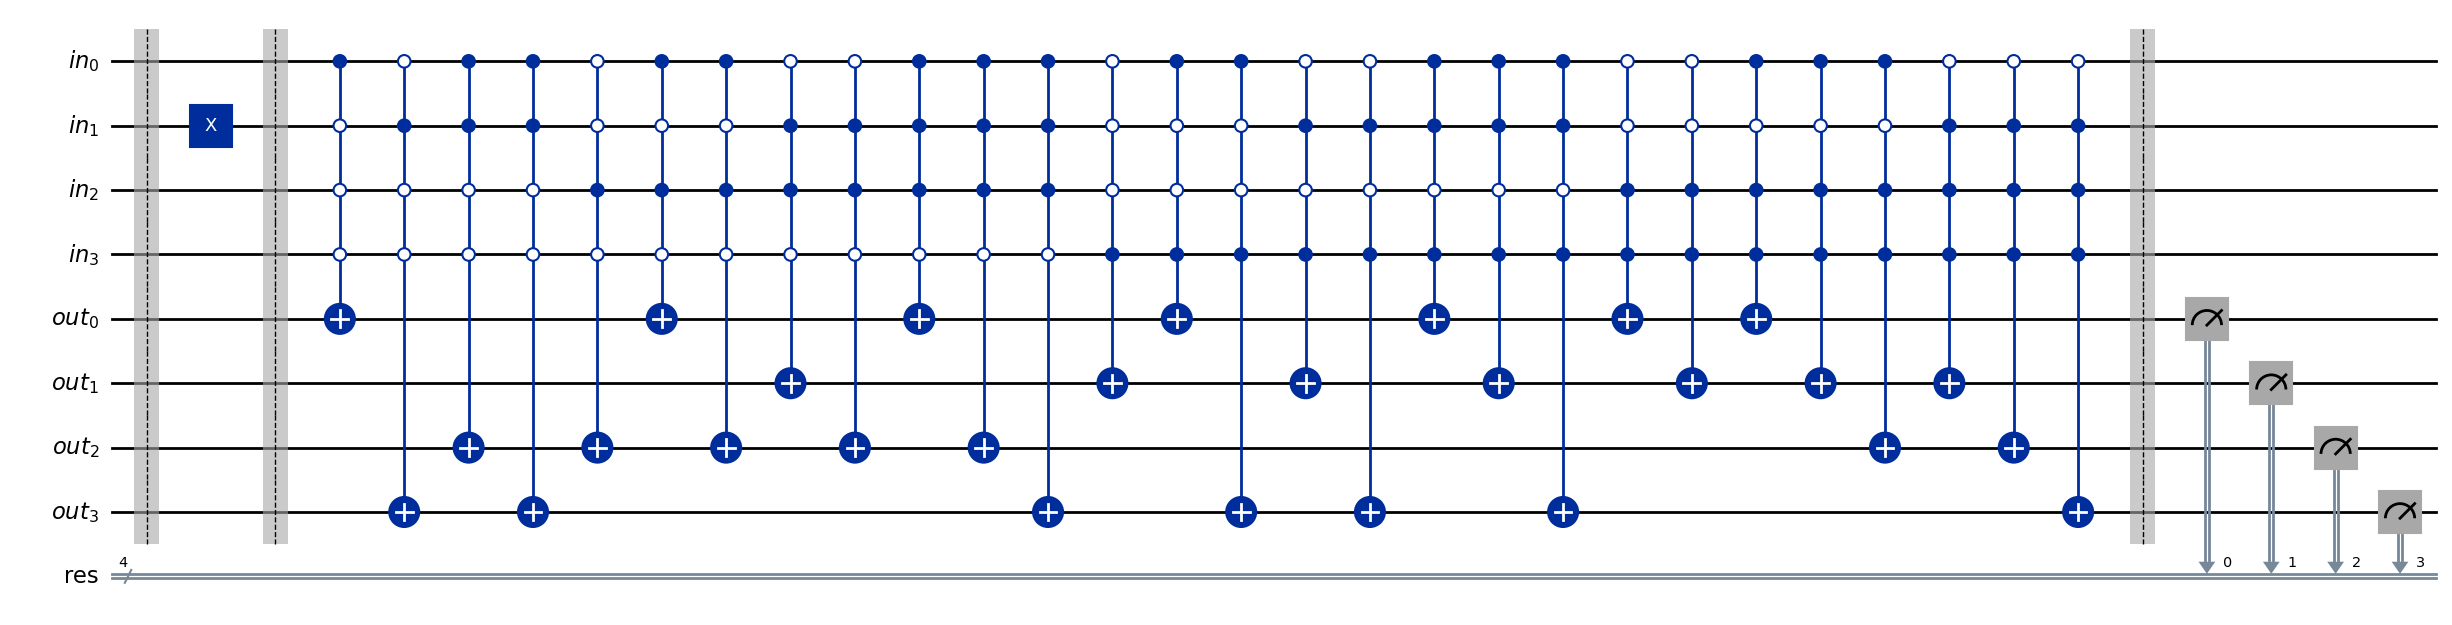

In [87]:
qc_enc.draw('mpl', fold=-1, filename='example-1-rsa-encrypt-circuit.png')

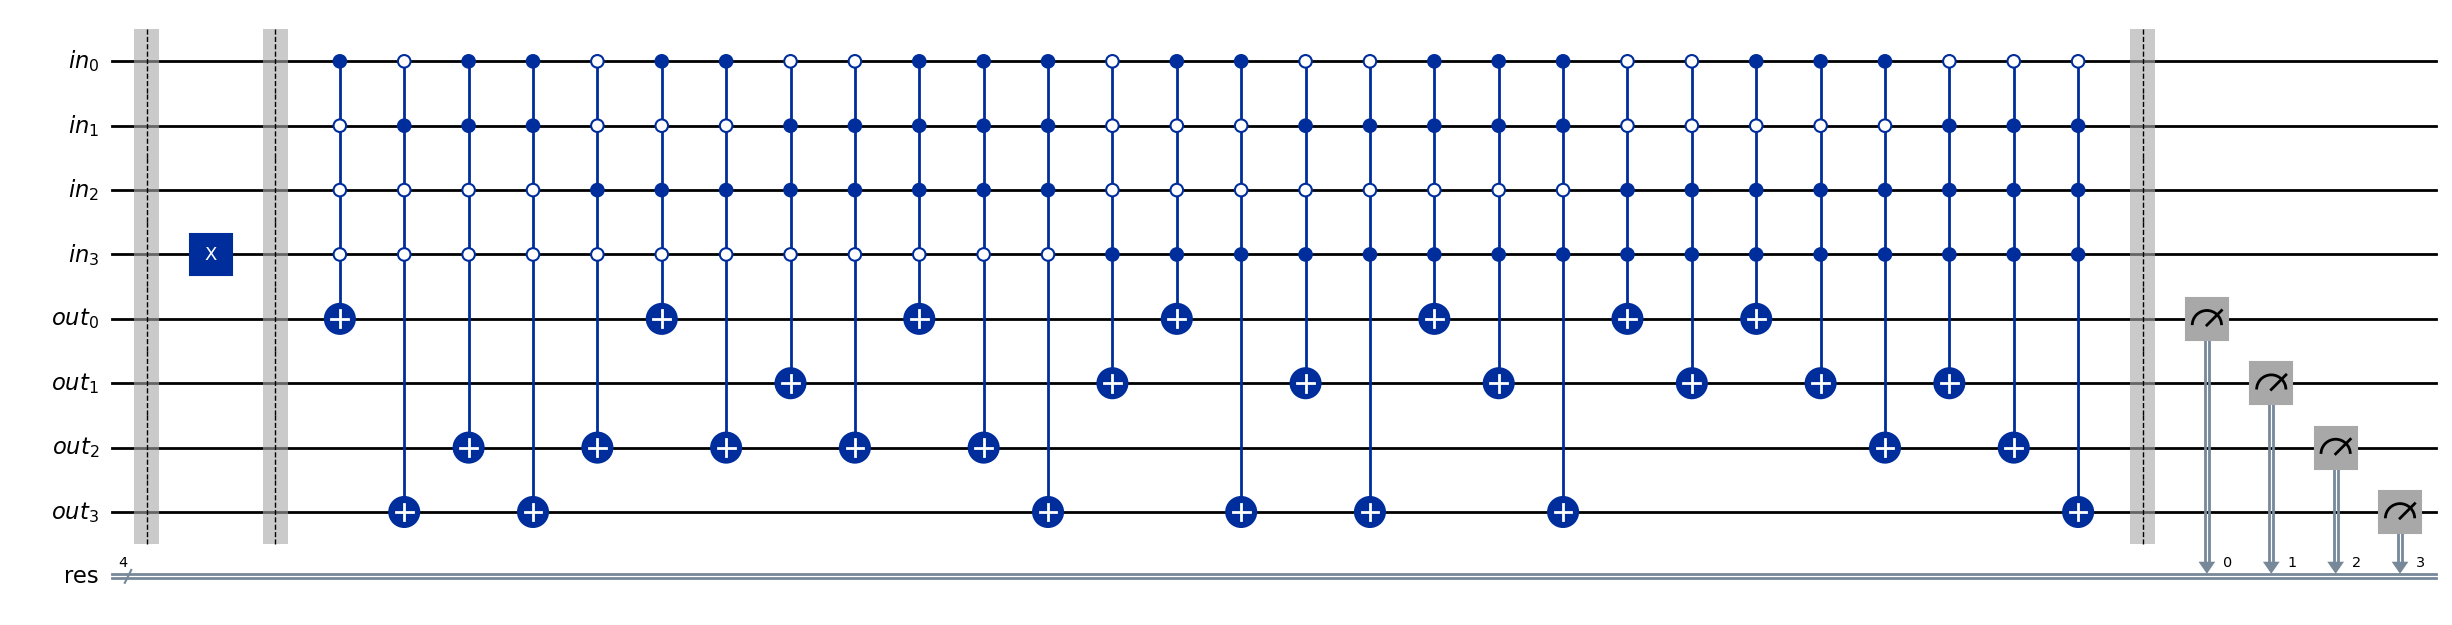

In [88]:
qc_dec.draw('mpl', fold=-1, filename='example-1-rsa-decrypt-circuit.png')

## Theory/Code Explained

### 1. RSA in four lines
- key setup: pick primes `p < q`, set `N = p*q` and `phi = (p-1)(q-1)`. choose `e` with `gcd(e, phi) = 1`, then `d = e^-1 mod phi`.
- encrypt: `C = M^e mod N`
- decrypt: `M = C^d mod N`
- why it works: `e*d = 1 (mod phi)`, so `M^(e*d) = M (mod N)` for every `0 <= M < N`. the code verifies this by brute force over all `M` in `range(N)`.

worked example (this notebook): `p,q = 3,5`, `N = 15`, `phi = 8`, `e = 3`, `d = 3`. message `M = 2` gives `C = 2^3 mod 15 = 8`, and decrypting gives `8^3 mod 15 = 512 mod 15 = 2`.

### 2. From a function to a circuit
a quantum circuit can only apply reversible (unitary) operations, so `x -> x^k mod N` cannot be applied directly (it is not one-to-one in general). the standard fix is an oracle that keeps the input and XORs the result into a second register:

`U_k : |x>|y> -> |x>|y XOR (x^k mod N)>`

- the output register starts at `|y=0>`, so `0 XOR f(x) = f(x)`.
- the input register `|x>` passes through unchanged, which makes the map a permutation of basis states (hence unitary).
- the same builder serves both directions: `k = e` encrypts, `k = d` decrypts.

### 3. How the oracle is built (lookup table)
`modexp_oracle` loops over every `x` in `0..N-1`:
1. compute `out = pow(x, k, N) = x^k mod N` classically.
2. for each bit that is 1 in `out`, add a multi-controlled X (`mcx`) targeting that output qubit.
3. the controls are all `n` input qubits, with `ctrl_state=x`, so the gate fires only when the input register equals the integer `x`.

so the circuit is a truth table written in gates. at most one `x` matches, so exactly the bits of `x^k mod N` get flipped in the output register.

### 4. Registers and bit order
- `n = N.bit_length()` qubits per register (input `in`, output `out`) plus `n` classical bits `res`, so `2n` qubits in total.
- `load_integer` sets the input register to `|value>` with qubit `i` holding bit `i` of the value (little-endian), using one `X` per 1-bit.
- qiskit prints measurement strings with bit 0 on the right, so `int(bitstring, 2)` reads the result back directly.

### 5. Code map
| step | code | classical / quantum |
|---|---|---|
| key setup, validation | `p, q, e -> N, phi, d, n` and the asserts | classical |
| bits to integer, padding | `int(M_bits, 2)`, identity pad | classical |
| encrypt | `run_oracle(M_padded, e, n, N)` | quantum (simulated) |
| serialize | `format(C, f"0{n}b")`, fixed width `n` | classical |
| transmit / receive | `received = C_bits` | classical |
| decrypt | `run_oracle(C_rx, d, n, N)` | quantum (simulated) |
| depad, bits | identity depad, `format(M_int2, f"0{m}b")` | classical |

`run_oracle` loads the input, applies `U_k`, measures the output register, and returns the integer. the input is a basis state and the oracle is deterministic, so the result is the same on every shot.

### 6. Constraints to remember
- the message value must be smaller than `N` (`int(M_bits, 2) < N`). a larger value is outside the oracle's domain, encrypts to the wrong thing, and does not round-trip.
- `p`, `q` must be distinct odd primes, and `1 < e < phi` with `gcd(e, phi) = 1`.
- the message length `m` can differ from `n`: the plaintext is formatted to `m` bits and the ciphertext to `n` bits.

### 7. What is (and isn't) quantum here
- the quantum part is only the modular exponentiation, and it is simulated on `AerSimulator` rather than run on hardware.
- the lookup table is computed classically with `pow(x, k, N)` for every `x`, so the circuit is not a quantum speedup. gate count grows roughly as `N * n`, exponential in qubit count, so this is practical only for small `N` (a few qubits per register).
- a scalable version would build modular exponentiation from arithmetic circuits (modular adders and multipliers with ancilla qubits), as in Shor's algorithm.
- identity padding and tiny primes are not secure. this is a teaching example of circuit structure.